# Generative AI Capstone Project: Recipe Generation using Fine-Tuned GPT-2
Author: Faheema Mohamed Maideen
Date: 
Course: Generative AI Capstone Project

# Generative Task
This project implements an ingredient-conditioned recipe generation system. Given a list of cooking ingredients as input, the model generates a complete recipe including a title and step-by-step cooking directions.

# Approach
The chosen approach is Transformer-based text generation, specifically fine-tuning a pretrained GPT-2 (small, 124M parameters) language model on the RecipeNLG dataset. GPT-2 is a decoder-only Transformer that excels at autoregressive text generation. Fine-tuning adapts the model's general English language knowledge to the domain-specific structure and vocabulary of cooking recipes.

# Why This Approach?
GPT-2 fine-tuning is preferred over training a Transformer from scratch because recipes require coherent multi-sentence generation with domain knowledge (cooking terminology, logical step ordering), which benefits from pretrained language understanding.
Ingredient-conditioned generation frames the task as a structured input-to-output problem, making it easy to evaluate whether the model uses the provided ingredients correctly.
The RecipeNLG dataset provides over 2 million recipes with semi-structured text, making it ideal for fine-tuning a generative language model.

# What the System Produces
The system takes a comma-separated list of ingredients and generates:

A recipe title relevant to the ingredients
Step-by-step cooking directions

# Dataset

Name: RecipeNLG (Bień et al., 2020)
Source: Kaggle - RecipeNLG
Size: 2,231,142 cooking recipes
License: For non-commercial research and educational purposes
Not synthetic or AI-generated — recipes were scraped from cooking websites

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch


In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"PyTorch device: {device}")

if device == "cuda":
    print(f"GPU detected: {torch.cuda.get_device_name(0)}")
    print(f"GPU memory: {torch.cuda.get_device_properties(0).total_mem / 1e9:.1f} GB")
else:
    print("No GPU detected. Training will run on CPU (slower but functional).")

PyTorch device: cpu
No GPU detected. Training will run on CPU (slower but functional).


In [5]:
DATA_PATH = './RecipeNLG_dataset.csv'

df = pd.read_csv(DATA_PATH)
print(f"Dataset loaded successfully: {len(df):,} recipes")
df.head()


Dataset loaded successfully: 2,231,142 recipes


,Unnamed: 0,title,ingredients,directions,link,source,NER
0,0,No-Bake Nut Cookies,"[""1 c. firmly packed brown sugar"", ""1/2 c. eva...","[""In a heavy 2-quart saucepan, mix brown sugar...",www.cookbooks.com/Recipe-Details.aspx?id=44874,Gathered,"[""brown sugar"", ""milk"", ""vanilla"", ""nuts"", ""bu..."
1,1,Jewell Ball'S Chicken,"[""1 small jar chipped beef, cut up"", ""4 boned ...","[""Place chipped beef on bottom of baking dish....",www.cookbooks.com/Recipe-Details.aspx?id=699419,Gathered,"[""beef"", ""chicken breasts"", ""cream of mushroom..."
2,2,Creamy Corn,"[""2 (16 oz.) pkg. frozen corn"", ""1 (8 oz.) pkg...","[""In a slow cooker, combine all ingredients. C...",www.cookbooks.com/Recipe-Details.aspx?id=10570,Gathered,"[""frozen corn"", ""cream cheese"", ""butter"", ""gar..."
3,3,Chicken Funny,"[""1 large whole chicken"", ""2 (10 1/2 oz.) cans...","[""Boil and debone chicken."", ""Put bite size pi...",www.cookbooks.com/Recipe-Details.aspx?id=897570,Gathered,"[""chicken"", ""chicken gravy"", ""cream of mushroo..."
4,4,Reeses Cups(Candy),"[""1 c. peanut butter"", ""3/4 c. graham cracker ...","[""Combine first four ingredients and press in ...",www.cookbooks.com/Recipe-Details.aspx?id=659239,Gathered,"[""peanut butter"", ""graham cracker crumbs"", ""bu..."


In [6]:
# Basic structure overview
print("=" * 60)
print("DATASET STRUCTURE")
print("=" * 60)
print(f"\nShape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"\nColumns: {list(df.columns)}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

DATASET STRUCTURE

Shape: 2,231,142 rows x 7 columns

Columns: ['Unnamed: 0', 'title', 'ingredients', 'directions', 'link', 'source', 'NER']

Data types:
Unnamed: 0      int64
title          object
ingredients    object
directions     object
link           object
source         object
NER            object
dtype: object

Memory usage: 2819.1 MB


In [7]:
# Check for missing values
print("MISSING VALUES")
print("=" * 60)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df)

MISSING VALUES
             Missing Count  Missing %
Unnamed: 0               0        0.0
title                    1        0.0
ingredients              0        0.0
directions               0        0.0
link                     0        0.0
source                   0        0.0
NER                      0        0.0


In [8]:
# Display first 5 rows in table format
df.head()

,Unnamed: 0,title,ingredients,directions,link,source,NER
0,0,No-Bake Nut Cookies,"[""1 c. firmly packed brown sugar"", ""1/2 c. eva...","[""In a heavy 2-quart saucepan, mix brown sugar...",www.cookbooks.com/Recipe-Details.aspx?id=44874,Gathered,"[""brown sugar"", ""milk"", ""vanilla"", ""nuts"", ""bu..."
1,1,Jewell Ball'S Chicken,"[""1 small jar chipped beef, cut up"", ""4 boned ...","[""Place chipped beef on bottom of baking dish....",www.cookbooks.com/Recipe-Details.aspx?id=699419,Gathered,"[""beef"", ""chicken breasts"", ""cream of mushroom..."
2,2,Creamy Corn,"[""2 (16 oz.) pkg. frozen corn"", ""1 (8 oz.) pkg...","[""In a slow cooker, combine all ingredients. C...",www.cookbooks.com/Recipe-Details.aspx?id=10570,Gathered,"[""frozen corn"", ""cream cheese"", ""butter"", ""gar..."
3,3,Chicken Funny,"[""1 large whole chicken"", ""2 (10 1/2 oz.) cans...","[""Boil and debone chicken."", ""Put bite size pi...",www.cookbooks.com/Recipe-Details.aspx?id=897570,Gathered,"[""chicken"", ""chicken gravy"", ""cream of mushroo..."
4,4,Reeses Cups(Candy),"[""1 c. peanut butter"", ""3/4 c. graham cracker ...","[""Combine first four ingredients and press in ...",www.cookbooks.com/Recipe-Details.aspx?id=659239,Gathered,"[""peanut butter"", ""graham cracker crumbs"", ""bu..."


In [9]:
# Display 5 detailed recipe samples
def display_recipe(row, index):
    """Pretty-print a single recipe for inspection."""
    print(f"{'=' * 60}")
    print(f"RECIPE #{index + 1}: {row['title']}")
    print(f"{'=' * 60}")

    # Parse ingredients (stored as string representation of list)
    try:
        ingredients = ast.literal_eval(row['ingredients'])
    except:
        ingredients = row['ingredients']

    print(f"\nIngredients ({len(ingredients)} items):")
    for ing in ingredients:
        print(f"  - {ing}")

    # Parse directions
    try:
        directions = ast.literal_eval(row['directions'])
    except:
        directions = row['directions']

    print(f"\nDirections ({len(directions)} steps):")
    for i, step in enumerate(directions, 1):
        print(f"  {i}. {step}")

    # Show NER (extracted ingredient names)
    try:
        ner = ast.literal_eval(row['NER'])
    except:
        ner = row['NER']
    print(f"\nNamed Entities (NER): {ner}")
    print(f"Source: {row.get('source', 'N/A')}")
    print()

# Show 5 random samples for variety
sample_indices = df.sample(5, random_state=42).index
for idx in sample_indices:
    display_recipe(df.iloc[idx], idx)

RECIPE #2015529: Marinated Flank Steak Recipe

Ingredients (10 items):
  - 1 1/2 pound flank steak
  - 1/2 c. finely minced green onions (scallions)
  - 1/2 c. dry red wine
  - 1/4 c. soy sauce
  - 3 tbsp. salad oil
  - 3 teaspoon sesame seeds
  - 2 teaspoon packed brown sugar
  - 1/4 teaspoon grnd black pepper
  - 1/4 teaspoon grnd ginger
  - 1 clove garlic, chopped

Directions (7 steps):
  1. Remove tenderloin from steak.
  2. Score meat.
  3. Combine remaining ingredients and pour over meat.
  4. Let marinate 24 hrs.
  5. Preheat grill.
  6. Broil or possibly grill.
  7. Slice thinly on an angle against the grain.

Named Entities (NER): ['flank steak', 'green onions', 'red wine', 'soy sauce', 'salad oil', 'sesame seeds', 'brown sugar', 'grnd black pepper', 'grnd ginger', 'clove garlic']
Source: Recipes1M

RECIPE #1608735: French Chicken Stew

Ingredients (18 items):
  - 1 tablespoon rosemary
  - 1 teaspoon thyme
  - 3 bay leaves
  - 1 teaspoon smoked paprika
  - 1 teaspoon pepper
  

In [10]:
# Compute text lengths for key columns
def safe_parse_list(val):
    """Parse string representation of list, return list."""
    try:
        parsed = ast.literal_eval(val)
        return parsed if isinstance(parsed, list) else [str(parsed)]
    except:
        return [str(val)]

# Sample 50,000 rows for faster analysis
sample_df = df.sample(50000, random_state=42).copy()

# Count number of ingredients per recipe
sample_df['num_ingredients'] = sample_df['ingredients'].apply(
    lambda x: len(safe_parse_list(x))
)

# Count number of direction steps per recipe
sample_df['num_steps'] = sample_df['directions'].apply(
    lambda x: len(safe_parse_list(x))
)

# Character length of full directions text
sample_df['directions_char_len'] = sample_df['directions'].apply(len)

# Title length
sample_df['title_len'] = sample_df['title'].apply(len)

print("TEXT LENGTH STATISTICS (sampled 50,000 recipes)")
print("=" * 60)
stats_cols = ['num_ingredients', 'num_steps', 'directions_char_len', 'title_len']
print(sample_df[stats_cols].describe().round(1))

TEXT LENGTH STATISTICS (sampled 50,000 recipes)
       num_ingredients  num_steps  directions_char_len  title_len
count          50000.0    50000.0              50000.0    50000.0
mean               8.7        6.6                509.2       23.9
std                4.0        5.4                460.6       11.5
min                1.0        1.0                  7.0        3.0
25%                6.0        3.0                222.0       16.0
50%                8.0        5.0                372.0       21.0
75%               11.0        8.0                645.0       29.0
max               76.0      151.0              11491.0      132.0


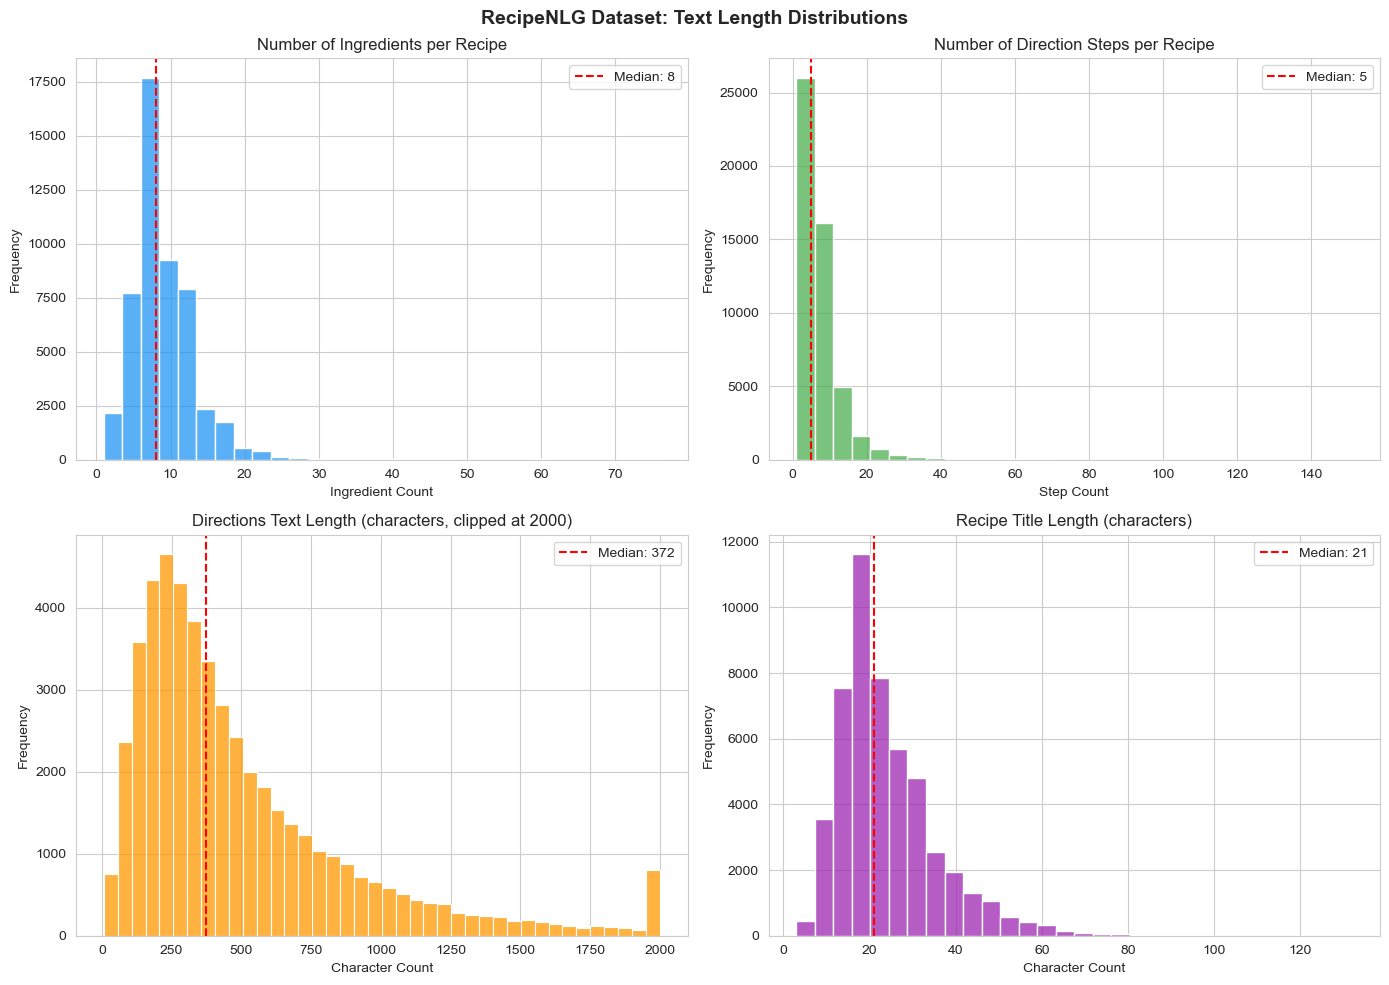

In [11]:
# Visualize distributions using seaborn + matplotlib
sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('RecipeNLG Dataset: Text Length Distributions',
             fontsize=14, fontweight='bold')

# Number of ingredients
sns.histplot(sample_df['num_ingredients'], bins=30, color='#2196F3',
             edgecolor='white', ax=axes[0, 0])
axes[0, 0].set_title('Number of Ingredients per Recipe')
axes[0, 0].set_xlabel('Ingredient Count')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(sample_df['num_ingredients'].median(),
                    color='red', linestyle='--',
                    label=f"Median: {sample_df['num_ingredients'].median():.0f}")
axes[0, 0].legend()

# Number of steps
sns.histplot(sample_df['num_steps'], bins=30, color='#4CAF50',
             edgecolor='white', ax=axes[0, 1])
axes[0, 1].set_title('Number of Direction Steps per Recipe')
axes[0, 1].set_xlabel('Step Count')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].axvline(sample_df['num_steps'].median(),
                    color='red', linestyle='--',
                    label=f"Median: {sample_df['num_steps'].median():.0f}")
axes[0, 1].legend()

# Directions character length
sns.histplot(sample_df['directions_char_len'].clip(upper=2000), bins=40,
             color='#FF9800', edgecolor='white', ax=axes[1, 0])
axes[1, 0].set_title('Directions Text Length (characters, clipped at 2000)')
axes[1, 0].set_xlabel('Character Count')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].axvline(sample_df['directions_char_len'].median(),
                    color='red', linestyle='--',
                    label=f"Median: {sample_df['directions_char_len'].median():.0f}")
axes[1, 0].legend()

# Title length
sns.histplot(sample_df['title_len'], bins=30, color='#9C27B0',
             edgecolor='white', ax=axes[1, 1])
axes[1, 1].set_title('Recipe Title Length (characters)')
axes[1, 1].set_xlabel('Character Count')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].axvline(sample_df['title_len'].median(),
                    color='red', linestyle='--',
                    label=f"Median: {sample_df['title_len'].median():.0f}")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

DATA SOURCE DISTRIBUTION
source
Gathered     1643098
Recipes1M     588044
Name: count, dtype: int64

Total unique sources: 2


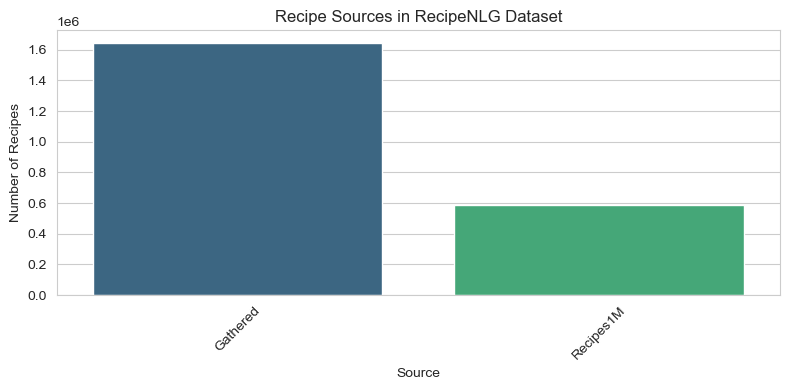

In [12]:
# Check distribution of data sources
if 'source' in df.columns:
    print("DATA SOURCE DISTRIBUTION")
    print("=" * 60)
    source_counts = df['source'].value_counts()
    print(source_counts)
    print(f"\nTotal unique sources: {df['source'].nunique()}")

    # Visualize source distribution
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.barplot(x=source_counts.index, y=source_counts.values,
                palette='viridis', ax=ax)
    ax.set_title('Recipe Sources in RecipeNLG Dataset')
    ax.set_xlabel('Source')
    ax.set_ylabel('Number of Recipes')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [13]:
def format_recipe_for_training(row):
    """
    Convert a dataset row into the formatted string used for GPT-2 fine-tuning.

    Uses NER column (clean ingredient names) as the input condition,
    and full title + directions as the generation target.
    """
    # Parse NER (clean ingredient names) for the input
    try:
        ner_list = ast.literal_eval(row['NER'])
    except:
        ner_list = [row['NER']]
    ingredients_str = ', '.join(ner_list)

    # Parse directions
    try:
        directions_list = ast.literal_eval(row['directions'])
    except:
        directions_list = [row['directions']]
    directions_str = ' '.join(directions_list)

    # Build formatted training text
    text = (
        f"<|startofrecipe|>\n"
        f"Ingredients: {ingredients_str}\n"
        f"Title: {row['title']}\n"
        f"Directions: {directions_str}\n"
        f"<|endofrecipe|>"
    )
    return text

# Preview 3 formatted samples
print("FORMATTED TRAINING SAMPLES")
print("These are what GPT-2 will learn from during fine-tuning.")
print()
for i in range(3):
    formatted = format_recipe_for_training(df.iloc[i])
    print(f"--- Sample {i+1} ({len(formatted)} chars) ---")
    print(formatted)
    print()

FORMATTED TRAINING SAMPLES
These are what GPT-2 will learn from during fine-tuning.

--- Sample 1 (499 chars) ---
<|startofrecipe|>
Ingredients: brown sugar, milk, vanilla, nuts, butter, bite size shredded rice biscuits
Title: No-Bake Nut Cookies
Directions: In a heavy 2-quart saucepan, mix brown sugar, nuts, evaporated milk and butter or margarine. Stir over medium heat until mixture bubbles all over top. Boil and stir 5 minutes more. Take off heat. Stir in vanilla and cereal; mix well. Using 2 teaspoons, drop and shape into 30 clusters on wax paper. Let stand until firm, about 30 minutes.
<|endofrecipe|>

--- Sample 2 (306 chars) ---
<|startofrecipe|>
Ingredients: beef, chicken breasts, cream of mushroom soup, sour cream
Title: Jewell Ball'S Chicken
Directions: Place chipped beef on bottom of baking dish. Place chicken on top of beef. Mix soup and cream together; pour over chicken. Bake, uncovered, at 275° for 3 hours.
<|endofrecipe|>

--- Sample 3 (308 chars) ---
<|startofrecipe|>
I

Approximately 98.0% of recipes fit within 512 tokens.
Median estimated token length: 132 tokens
95th percentile token length: 392 tokens


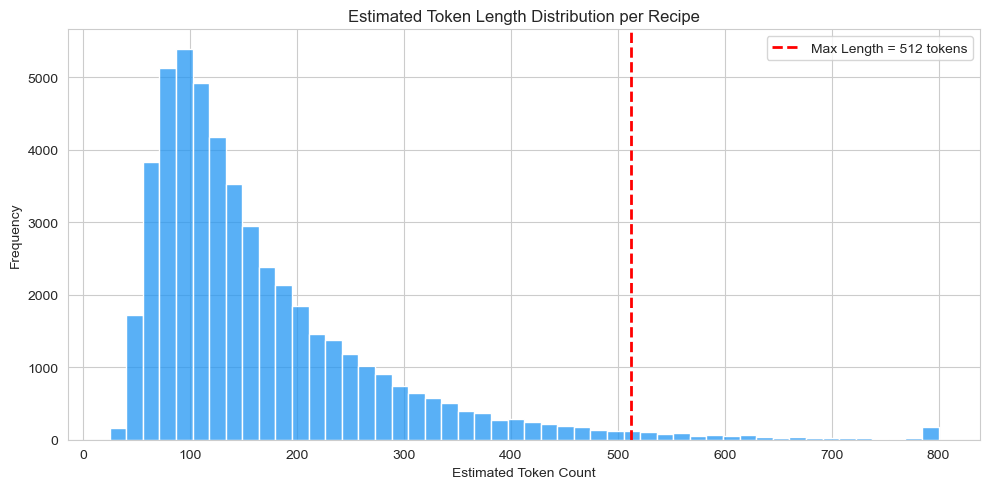

In [14]:
# Check: how many recipes fit within 512 tokens (approximate via character count)
# GPT-2 averages ~4 characters per token
approx_token_len = sample_df.apply(
    lambda row: len(format_recipe_for_training(row)) / 4, axis=1
)

within_512 = (approx_token_len <= 512).mean() * 100
print(f"Approximately {within_512:.1f}% of recipes fit within 512 tokens.")
print(f"Median estimated token length: {approx_token_len.median():.0f} tokens")
print(f"95th percentile token length: {approx_token_len.quantile(0.95):.0f} tokens")

# Visualize token length distribution
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(approx_token_len.clip(upper=800), bins=50,
             color='#2196F3', edgecolor='white', ax=ax)
ax.axvline(512, color='red', linestyle='--', linewidth=2,
           label='Max Length = 512 tokens')
ax.set_title('Estimated Token Length Distribution per Recipe')
ax.set_xlabel('Estimated Token Count')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()